In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/revision/supplement"
setup_plotting(figure_dir)

import os

# from matplotlib.lines import Line2D
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr
Arial font found!


# Iterate over all samples to get the sample specific expansions

In [12]:
with open(
    "data/tcr-seq/processed/refdfdic_alignednaming.pkl",
    "rb",
) as handle:
    refdic = pickle.load(handle)

In [13]:
with open(
    "data/tcr-seq/processed/refdic_p126.pkl",
    "rb",
) as f:
    refdic["P126K"] = pickle.load(f)

In [14]:
refclones = {}
for key in refdic.keys():
    df = refdic[key]
    cd4 = df[df["celltype"] == "CD4+"]
    cd8 = df[df["celltype"] == "CD8+"]
    x4 = cd4[["TRA", "TRB"]].value_counts().value_counts().sort_index().index
    y4 = cd4[["TRA", "TRB"]].value_counts().value_counts().sort_index().values
    x8 = cd8[["TRA", "TRB"]].value_counts().value_counts().sort_index().index
    y8 = cd8[["TRA", "TRB"]].value_counts().value_counts().sort_index().values
    refclones[key] = (x4, y4, x8, y8)

In [15]:
# Initialize empty Series
cd4_series = pd.Series(dtype=int)
cd8_series = pd.Series(dtype=int)

# Iterate over refclones dictionary
for sample, (x4, y4, x8, y8) in refclones.items():
    s4 = pd.Series(data=y4, index=x4)
    s8 = pd.Series(data=y8, index=x8)

    cd4_series = cd4_series.add(s4, fill_value=0)
    cd8_series = cd8_series.add(s8, fill_value=0)

# Convert to integers and sort
cd4_series = cd4_series.sort_index().astype(int)
cd8_series = cd8_series.sort_index().astype(int)

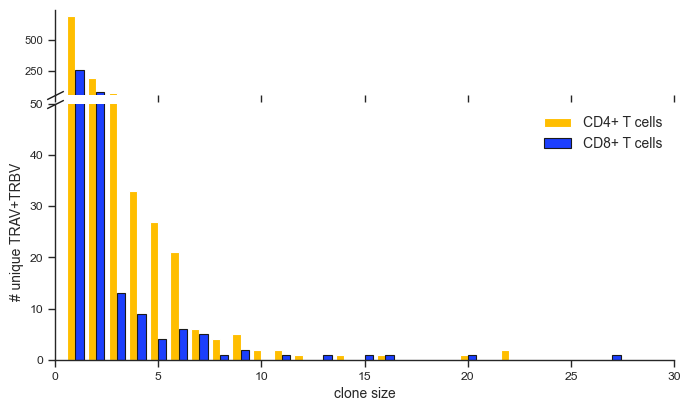

In [16]:
scaler = 0.7
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(10 * scaler, 6 * scaler),
    gridspec_kw={"height_ratios": [1, 3]},
)

# Colors
cd4color = "#ffbe00ff"
cd8color = "#1c3ffdff"

# Data
x4 = cd4_series.index
y4 = cd4_series.values
x8 = cd8_series.index
y8 = cd8_series.values

# Set break point
break_point = 50
break_height = 1
ymax_top = max(max(y4), max(y8))

# Top plot (above break)
ax1.bar(x4 - 0.2, y4, color=cd4color, width=0.4)
ax1.bar(x8 + 0.2, y8, color=cd8color, edgecolor="k", width=0.4)
ax1.set_ylim(break_point + break_height, ymax_top + 50)

# Bottom plot (below break)
ax2.bar(x4 - 0.2, y4, color=cd4color, label="CD4+ T cells", width=0.4)
ax2.bar(x8 + 0.2, y8, color=cd8color, edgecolor="k", label="CD8+ T cells", width=0.4)
ax2.set_ylim(0, break_point)

# Axis & break marks
ax1.spines["bottom"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax1.tick_params(labeltop=False, labelsize=8)
ax2.xaxis.tick_bottom()

# Diagonal break marks
d = 0.5
kwargs = {
    "marker": [(-1, -d), (1, d)],
    "markersize": 12,
    "linestyle": "none",
    "color": "k",
    "mec": "k",
    "mew": 1,
    "clip_on": False,
}
ax1.plot([0], [0], transform=ax1.transAxes, **kwargs)
ax2.plot([0], [1], transform=ax2.transAxes, **kwargs)

# Labels and layout
ax2.set_xlabel("clone size", fontsize=10)
ax2.set_ylabel("# unique TRAV+TRBV", fontsize=10)
# ax1.set_title('1 TCRseq sample clone size distribution')
ax2.legend(frameon=False, fontsize=10)
ax2.set_xlim(0, 30)
sns.despine(ax=ax1, bottom=True)
sns.despine(ax=ax2, right=True)
# ax1.set_xticks([])

# sns.despine()
plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.savefig(
    os.path.join(figure_dir, "SUPP02_allANCA_clonesize_brokenY.pdf"),
    dpi=300,
    bbox_inches="tight",
)

# Expansion histogram

In [17]:
patients = []
cd4_singlets, cd4_expanded = [], []
cd8_singlets, cd8_expanded = [], []

for pat in sorted(refdic.keys()):
    patdf = refdic[pat]
    cd4 = patdf[patdf["celltype"] == "CD4+"]
    cd8 = patdf[patdf["celltype"] == "CD8+"]
    srs4 = cd4[["TRA", "TRB"]].value_counts().value_counts()
    srs8 = cd8[["TRA", "TRB"]].value_counts().value_counts()
    sing4, exp4 = srs4[1], srs4.sum() - srs4[1]
    sing8, exp8 = srs8[1], srs8.sum() - srs8[1]

    patients.append(pat)
    cd4_singlets.append(sing4)
    cd4_expanded.append(exp4)
    cd8_singlets.append(sing8)
    cd8_expanded.append(exp8)

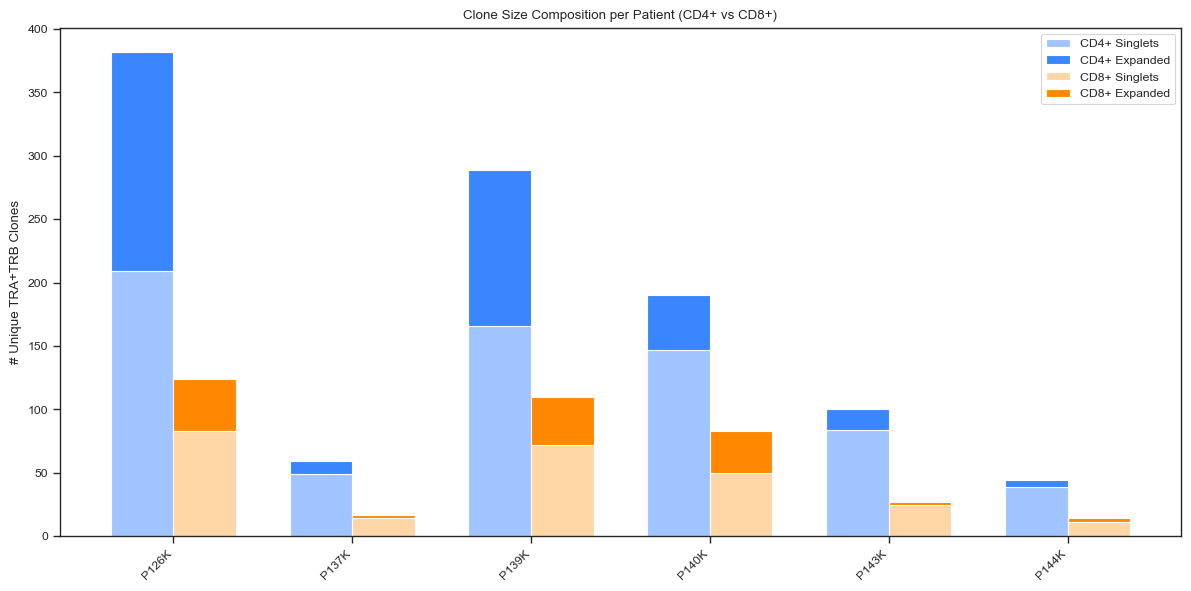

In [18]:
x = np.arange(len(patients))  # patient positions
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# CD4+ bars
ax.bar(x - width / 2, cd4_singlets, width, label="CD4+ Singlets", color="#A0C4FF")
ax.bar(
    x - width / 2,
    cd4_expanded,
    width,
    bottom=cd4_singlets,
    label="CD4+ Expanded",
    color="#3A86FF",
)

# CD8+ bars
ax.bar(x + width / 2, cd8_singlets, width, label="CD8+ Singlets", color="#FFD6A5")
ax.bar(
    x + width / 2,
    cd8_expanded,
    width,
    bottom=cd8_singlets,
    label="CD8+ Expanded",
    color="#FF8800",
)

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=45, ha="right")
ax.set_ylabel("# Unique TRA+TRB Clones")
ax.set_title("Clone Size Composition per Patient (CD4+ vs CD8+)")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
patient_mapping = {p: f"TCRseq {i}" for i, p in enumerate(patients)}
patients = [patient_mapping[p] for p in patients]

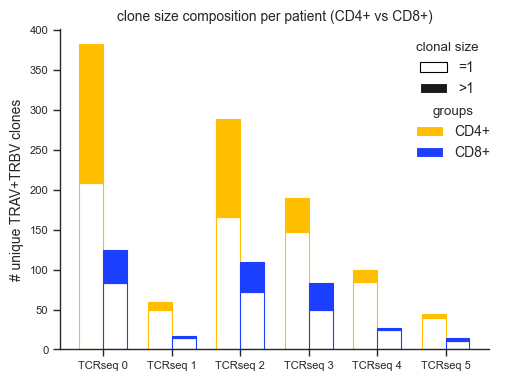

In [20]:
x = np.arange(len(patients))  # patient positions
width = 0.35

scaler = 0.65
fig, ax = plt.subplots(figsize=(8 * scaler, 6 * scaler))

# Color scheme
cd4color = "#ffbe00ff"
cd8color = "#1c3ffdff"

# CD4+ bars
cd4_bottom = np.zeros(len(patients))
for i in range(2):  # 0 = singlets, 1 = expanded
    if i == 0:
        ax.bar(
            x - width / 2,
            cd4_singlets,
            width,
            bottom=cd4_bottom,
            fill=False,
            edgecolor=cd4color,
            label="CD4+ Singlets",
        )
    else:
        ax.bar(
            x - width / 2,
            cd4_expanded,
            width,
            bottom=cd4_bottom,
            color=cd4color,
            edgecolor=cd4color,
            label="CD4+ Expanded",
        )
    cd4_bottom += cd4_singlets if i == 0 else cd4_expanded

# CD8+ bars
cd8_bottom = np.zeros(len(patients))
for i in range(2):  # 0 = singlets, 1 = expanded
    if i == 0:
        ax.bar(
            x + width / 2,
            cd8_singlets,
            width,
            bottom=cd8_bottom,
            fill=False,
            edgecolor=cd8color,
            label="CD8+ Singlets",
        )
    else:
        ax.bar(
            x + width / 2,
            cd8_expanded,
            width,
            bottom=cd8_bottom,
            color=cd8color,
            edgecolor=cd8color,
            label="CD8+ Expanded",
        )
    cd8_bottom += cd8_singlets if i == 0 else cd8_expanded

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=0)
ax.set_ylabel("# unique TRAV+TRBV clones", fontsize=10)
ax.set_title("clone size composition per patient (CD4+ vs CD8+)", fontsize=10)

# Clean and grouped legend like in B
color_patches = [
    Patch(facecolor="none", edgecolor="black", label="=1"),
    Patch(facecolor="k", label=">1"),
]
group_patches = [
    Patch(facecolor=cd4color, label="CD4+"),  # left bars
    Patch(facecolor=cd8color, label="CD8+"),  # right bars
]
legend1 = ax.legend(
    handles=color_patches,
    title="clonal size",
    loc="upper left",
    bbox_to_anchor=(0.8, 1),
    fontsize=10,
    frameon=False,
)
legend2 = ax.legend(
    handles=group_patches,
    title="groups",
    loc="upper left",
    bbox_to_anchor=(0.8, 0.8),
    fontsize=10,
    frameon=False,
)
ax.add_artist(legend1)
ax.tick_params(labelsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, "Supp02_perSample_cloneDistribution.pdf"),
    dpi=300,
    bbox_inches="tight",
)
# plt.show()